In [1]:
!pip install catboost
!pip install pymongo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 20.5 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from joblib import dump, load
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from dataclasses import dataclass
from pymongo import MongoClient

###Data load

csv file

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Work_space/Kaushi/ASL_detection/artifact/data/ASL_cleaned_ISO_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33175 entries, 0 to 33174
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   x0      33175 non-null  int64 
 1   x1      33175 non-null  int64 
 2   x2      33175 non-null  int64 
 3   x3      33175 non-null  int64 
 4   x4      33175 non-null  int64 
 5   x5      33175 non-null  int64 
 6   x6      33175 non-null  int64 
 7   x7      33175 non-null  int64 
 8   x8      33175 non-null  int64 
 9   x9      33175 non-null  int64 
 10  x10     33175 non-null  int64 
 11  x11     33175 non-null  int64 
 12  x12     33175 non-null  int64 
 13  x13     33175 non-null  int64 
 14  x14     33175 non-null  int64 
 15  x15     33175 non-null  int64 
 16  x16     33175 non-null  int64 
 17  x17     33175 non-null  int64 
 18  x18     33175 non-null  int64 
 19  x19     33175 non-null  int64 
 20  x20     33175 non-null  int64 
 21  y0      33175 non-null  int64 
 22  y1      33175 non-null

mongo db

In [3]:

def mongodb_Load(uri,db,collection):
    # Replace with your MongoDB Atlas connection string
    client = MongoClient(uri)

    # List all databases
    databases = client.list_database_names()
    print(databases)

    db = client['asl_land_mark_detection']

    # List all collections in the database
    collections = db.list_collection_names()

    # Print the collections
    print("Collections in database:", collections)


    collection = db[collection]

    # Fetch all documents in the collection
    documents = collection.find()

    data = list(documents)

    # Convert to DataFrame
    df = pd.DataFrame(data)

    print(df)

    return df

In [ ]:
uri="XXXXXXXXXXXXXXXXXXXXXX"
db='asl_land_mark_detection'
collection='ISO_collection'
df=mongodb_Load(uri,db,collection)

['asl_land_mark_detection', 'sample_mflix', 'admin', 'local']
Collections in database: ['ISO_collection', 'original', 'IQR_collection']
                            _id   x0   x1   x2   x3   x4   x5   x6   x7   x8  \
0      67e2eadbb9f91bb501294388  126  177  192  167  144  211  213  180  156   
1      67e2eadbb9f91bb501294389  125  186  192  158  132  216  217  188  163   
2      67e2eadbb9f91bb50129438a  163  103   90  124  163   88   70   82   93   
3      67e2eadbb9f91bb50129438b  157  111  106  136  164  132  106   83   73   
4      67e2eadbb9f91bb50129438c  134  192  214  177  136  191  218  229  222   
...                         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
26959  67e2eadbb9f91bb50129acd7  225  204  165  127   94  113   88   89   96   
26960  67e2eadbb9f91bb50129acd8  235  209  167  126   90  124   93   77   64   
26961  67e2eadbb9f91bb50129acd9  228  206  168  131   97  132  100   92   90   
26962  67e2eadbb9f91bb50129acda  227  203  165  128   96  128   

In [44]:
df.describe(include="all")

,_id,x0,x1,x2,x3,x4,x5,x6,x7,x8,...,z12,z13,z14,z15,z16,z17,z18,z19,z20,label
count,26964,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,...,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964.000000,26964
unique,26964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28
top,67e2eadbb9f91bb501294388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1096
mean,NaN,153.725115,170.798583,178.581145,171.996514,161.926569,161.831627,159.351209,158.333185,157.612743,...,-13.376057,-4.516058,-12.070242,-12.562009,-10.815977,-5.899236,-11.503412,-11.342865,-9.847575,NaN
std,NaN,48.974707,41.557165,42.885188,42.565614,49.580175,32.470881,38.499220,45.552144,53.604990,...,10.017673,7.641487,8.910603,8.187782,8.126510,8.060533,8.780993,8.446843,8.554000,NaN
min,NaN,10.000000,32.000000,39.000000,33.000000,28.000000,46.000000,42.000000,30.000000,5.000000,...,-90.000000,-63.000000,-78.000000,-70.000000,-75.000000,-58.000000,-69.000000,-66.000000,-72.000000,NaN
25%,NaN,127.000000,145.000000,158.000000,147.000000,131.000000,139.000000,127.000000,117.000000,115.000000,...,-17.000000,-6.000000,-16.000000,-16.000000,-14.000000,-8.000000,-15.000000,-14.000000,-13.000000,NaN
50%,NaN,148.000000,174.000000,189.000000,176.000000,154.000000,171.000000,170.000000,172.000000,171.000000,...,-12.000000,-3.000000,-11.000000,-12.000000,-10.000000,-4.000000,-10.000000,-10.000000,-8.000000,NaN
75%,NaN,175.000000,194.000000,208.000000,203.000000,200.000000,184.000000,188.000000,192.000000,195.000000,...,-8.000000,0.000000,-7.000000,-8.000000,-6.000000,-2.000000,-6.000000,-6.000000,-5.000000,NaN


In [45]:
#label=list(df["0"])
label=list(df["label"])
df['Category']=[x.upper()for x in label]
df.drop(['_id',],axis=1,inplace=True)
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,z13,z14,z15,z16,z17,z18,z19,z20,label,Category
0,126,177,192,167,144,211,213,180,156,167,...,0,-21,-24,-19,0,-17,-19,-15,N,N
1,125,186,192,158,132,216,217,188,163,167,...,1,-21,-29,-26,0,-18,-24,-22,N,N
2,163,103,90,124,163,88,70,82,93,134,...,-7,-23,-20,-13,-11,-21,-18,-12,N,N
3,157,111,106,136,164,132,106,83,73,166,...,-3,-15,-15,-10,-10,-16,-14,-9,N,N
4,134,192,214,177,136,191,218,229,222,152,...,-6,-24,-24,-17,-10,-21,-19,-13,N,N


In [46]:
df.columns

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'y0', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10',
       'y11', 'y12', 'y13', 'y14', 'y15', 'y16', 'y17', 'y18', 'y19', 'y20',
       'z0', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10',
       'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z20',
       'label', 'Category'],
      dtype='object')

###Classification_model (label encoding)

In [47]:
from sklearn.preprocessing import LabelEncoder
# Initialize the LabelEncoder
le = LabelEncoder()

# Fit and transform the 'Category' column
df['Category_Encoded'] = le.fit_transform(df['Category'])

In [48]:
# Create a mapping of categories to encoded values
category_mapping = dict(zip( le.transform(le.classes_),le.classes_))

print("classes:")
print(le.classes_)

print("\nCategory to Encoding Mapping:")
print(category_mapping)

classes:
['A' 'B' 'C' 'D' 'DEL' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q'
 'R' 'S' 'SPACE' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

Category to Encoding Mapping:
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'DEL', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'SPACE', 21: 'T', 22: 'U', 23: 'V', 24: 'W', 25: 'X', 26: 'Y', 27: 'Z'}


In [49]:
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,z14,z15,z16,z17,z18,z19,z20,label,Category,Category_Encoded
0,126,177,192,167,144,211,213,180,156,167,...,-21,-24,-19,0,-17,-19,-15,N,N,14
1,125,186,192,158,132,216,217,188,163,167,...,-21,-29,-26,0,-18,-24,-22,N,N,14
2,163,103,90,124,163,88,70,82,93,134,...,-23,-20,-13,-11,-21,-18,-12,N,N,14
3,157,111,106,136,164,132,106,83,73,166,...,-15,-15,-10,-10,-16,-14,-9,N,N,14
4,134,192,214,177,136,191,218,229,222,152,...,-24,-24,-17,-10,-21,-19,-13,N,N,14


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV


In [51]:
X=df.iloc[:,:63].values
Y=df.iloc[:,-1].values

X=X/330

print(X.shape)
print(Y.shape)

(26964, 63)
(26964,)


In [53]:
print(X)
print(Y)

[[ 0.38181818  0.53636364  0.58181818 ... -0.05151515 -0.05757576
  -0.04545455]
 [ 0.37878788  0.56363636  0.58181818 ... -0.05454545 -0.07272727
  -0.06666667]
 [ 0.49393939  0.31212121  0.27272727 ... -0.06363636 -0.05454545
  -0.03636364]
 ...
 [ 0.69090909  0.62424242  0.50909091 ...  0.0030303  -0.0030303
  -0.00909091]
 [ 0.68787879  0.61515152  0.5        ...  0.00909091  0.0030303
   0.        ]
 [ 0.70909091  0.63030303  0.5        ...  0.00909091  0.
  -0.00606061]]
[14 14 14 ...  4  4  4]


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)


In [55]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot  as plt
import seaborn as sns

def plot_confusion_matrix(model, X_test, y_test,save_path):
    '''Function to plot confusion matrix for the passed model and the data'''

    sentiment_classes = le.classes_
    # use model to do the prediction
    y_pred = model.predict(X_test)
    # compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # plot confusion matrix
    plt.figure(figsize=(20,20))
    sns.heatmap(cm, cmap=plt.cm.Blues, annot=True, fmt='d',
                xticklabels=sentiment_classes,
                yticklabels=sentiment_classes)
    plt.title('Confusion matrix', fontsize=16)
    plt.xlabel('Actual label', fontsize=12)
    plt.ylabel('Predicted label', fontsize=12)



    # Save the plot
    plt.savefig(os.path.join(save_path,"confision_matrix"))
    plt.show()
    plt.close()  # Close the figure to prevent display issues



    print('Classification Report:')
    report=classification_report(y_test, y_pred)
    print(classification_report(y_test, y_pred))


    # Define the file path
    report_path = os.path.join(save_path, "accuracy_report.txt")

    # Save accuracy and report to a TXT file
    with open(report_path, "w") as f:
        f.write("Classification Report:\n")
        f.write(report)

    print(f"Accuracy report saved at: {report_path}")

    return

### RFC

In [56]:
# Initialize the RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,random_state=42)

In [18]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],         # Number of trees
    'max_depth': [None, 10, 20],            # Maximum depth of trees
    'min_samples_split': [2, 5, 10],        # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],          # Minimum samples at leaf node
    'bootstrap': [True, False]              # Whether to use bootstrapping
}

In [19]:
# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the best model on the full training set
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


KeyboardInterrupt: 

In [57]:
# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Directory 'artifact/randomforest' created successfully!


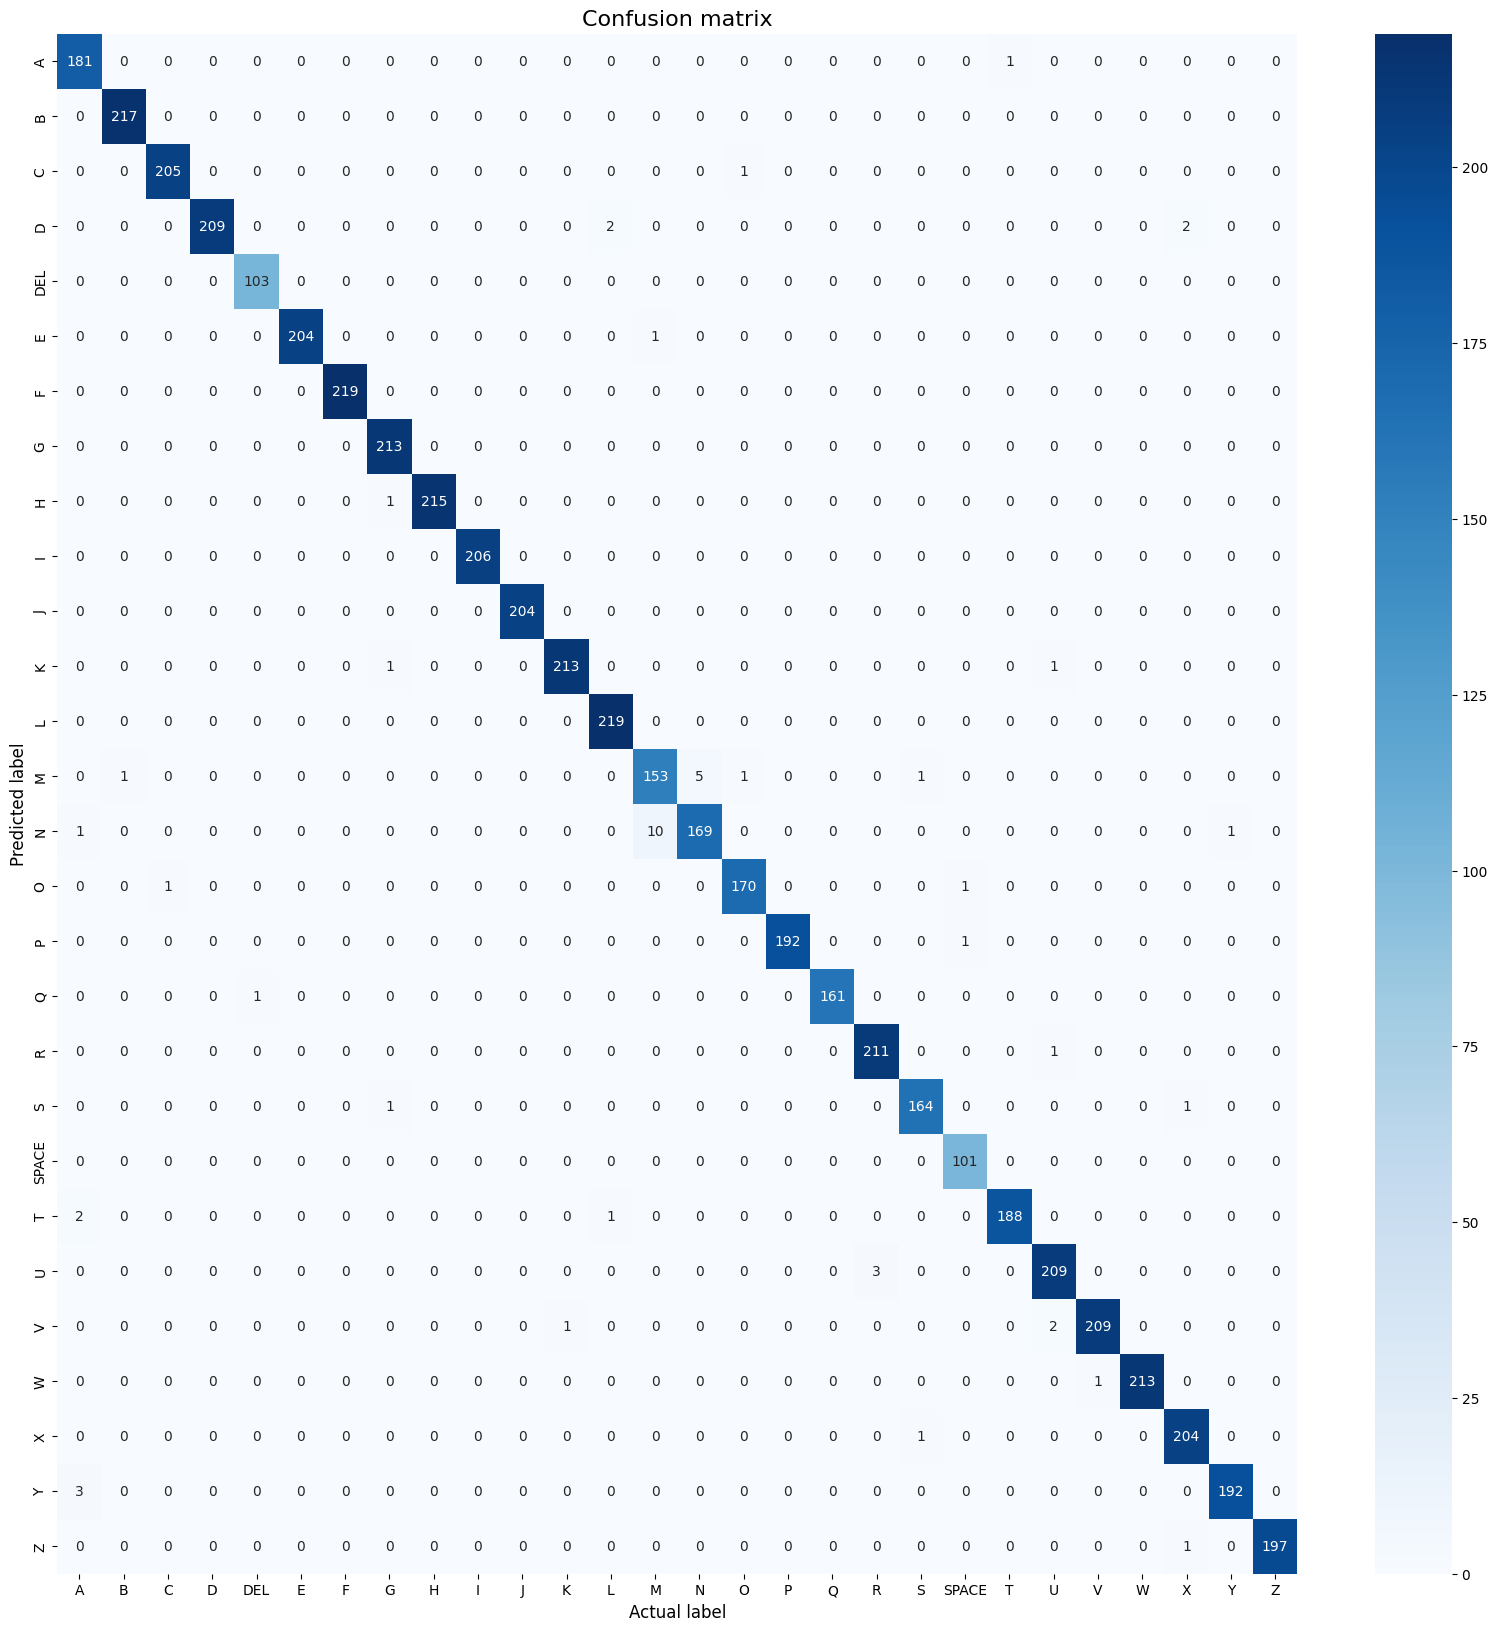

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       182
           1       1.00      1.00      1.00       217
           2       1.00      1.00      1.00       206
           3       1.00      0.98      0.99       213
           4       0.99      1.00      1.00       103
           5       1.00      1.00      1.00       205
           6       1.00      1.00      1.00       219
           7       0.99      1.00      0.99       213
           8       1.00      1.00      1.00       216
           9       1.00      1.00      1.00       206
          10       1.00      1.00      1.00       204
          11       1.00      0.99      0.99       215
          12       0.99      1.00      0.99       219
          13       0.93      0.95      0.94       161
          14       0.97      0.93      0.95       181
          15       0.99      0.99      0.99       172
          16       1.00      0.99      1.00       193
    

In [58]:
import os

# Define the path
random_dir = "artifact/randomforest"
# Create the directory if it does not exist
os.makedirs(random_dir, exist_ok=True)

print(f"Directory '{random_dir}' created successfully!")


# Save the model to a file
joblib.dump(rf, os.path.join(random_dir,'random_forest_model_scaled_XYZ.joblib'))

# Save the LabelEncoder
joblib.dump(le, os.path.join(random_dir,'label_encoder.pkl'))


plot_confusion_matrix(rf, X_test, y_test,random_dir)

### GBC

In [59]:
# Initialize the model
gbm = GradientBoostingClassifier(n_estimators=10, learning_rate=0.2, max_depth=8, random_state=42,verbose= 1)


In [60]:
# Train the model
gbm.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           0.2048            2.25m
         2           0.1104            2.20m
         3           0.0711            1.99m
         4           0.0485            1.77m
         5           0.0331            1.49m
         6           0.0229            1.20m
         7           0.0160           54.39s
         8           0.0112           37.38s
         9           0.0078           18.75s
        10           0.0055            0.00s


GradientBoostingClassifier(learning_rate=0.2, max_depth=8, n_estimators=10,
                           random_state=42, verbose=1)

In [61]:
gbm.predict(X_test)

array([ 8,  7, 25, ..., 26, 27,  8])

Directory 'artifact/gradian_boost' created successfully!


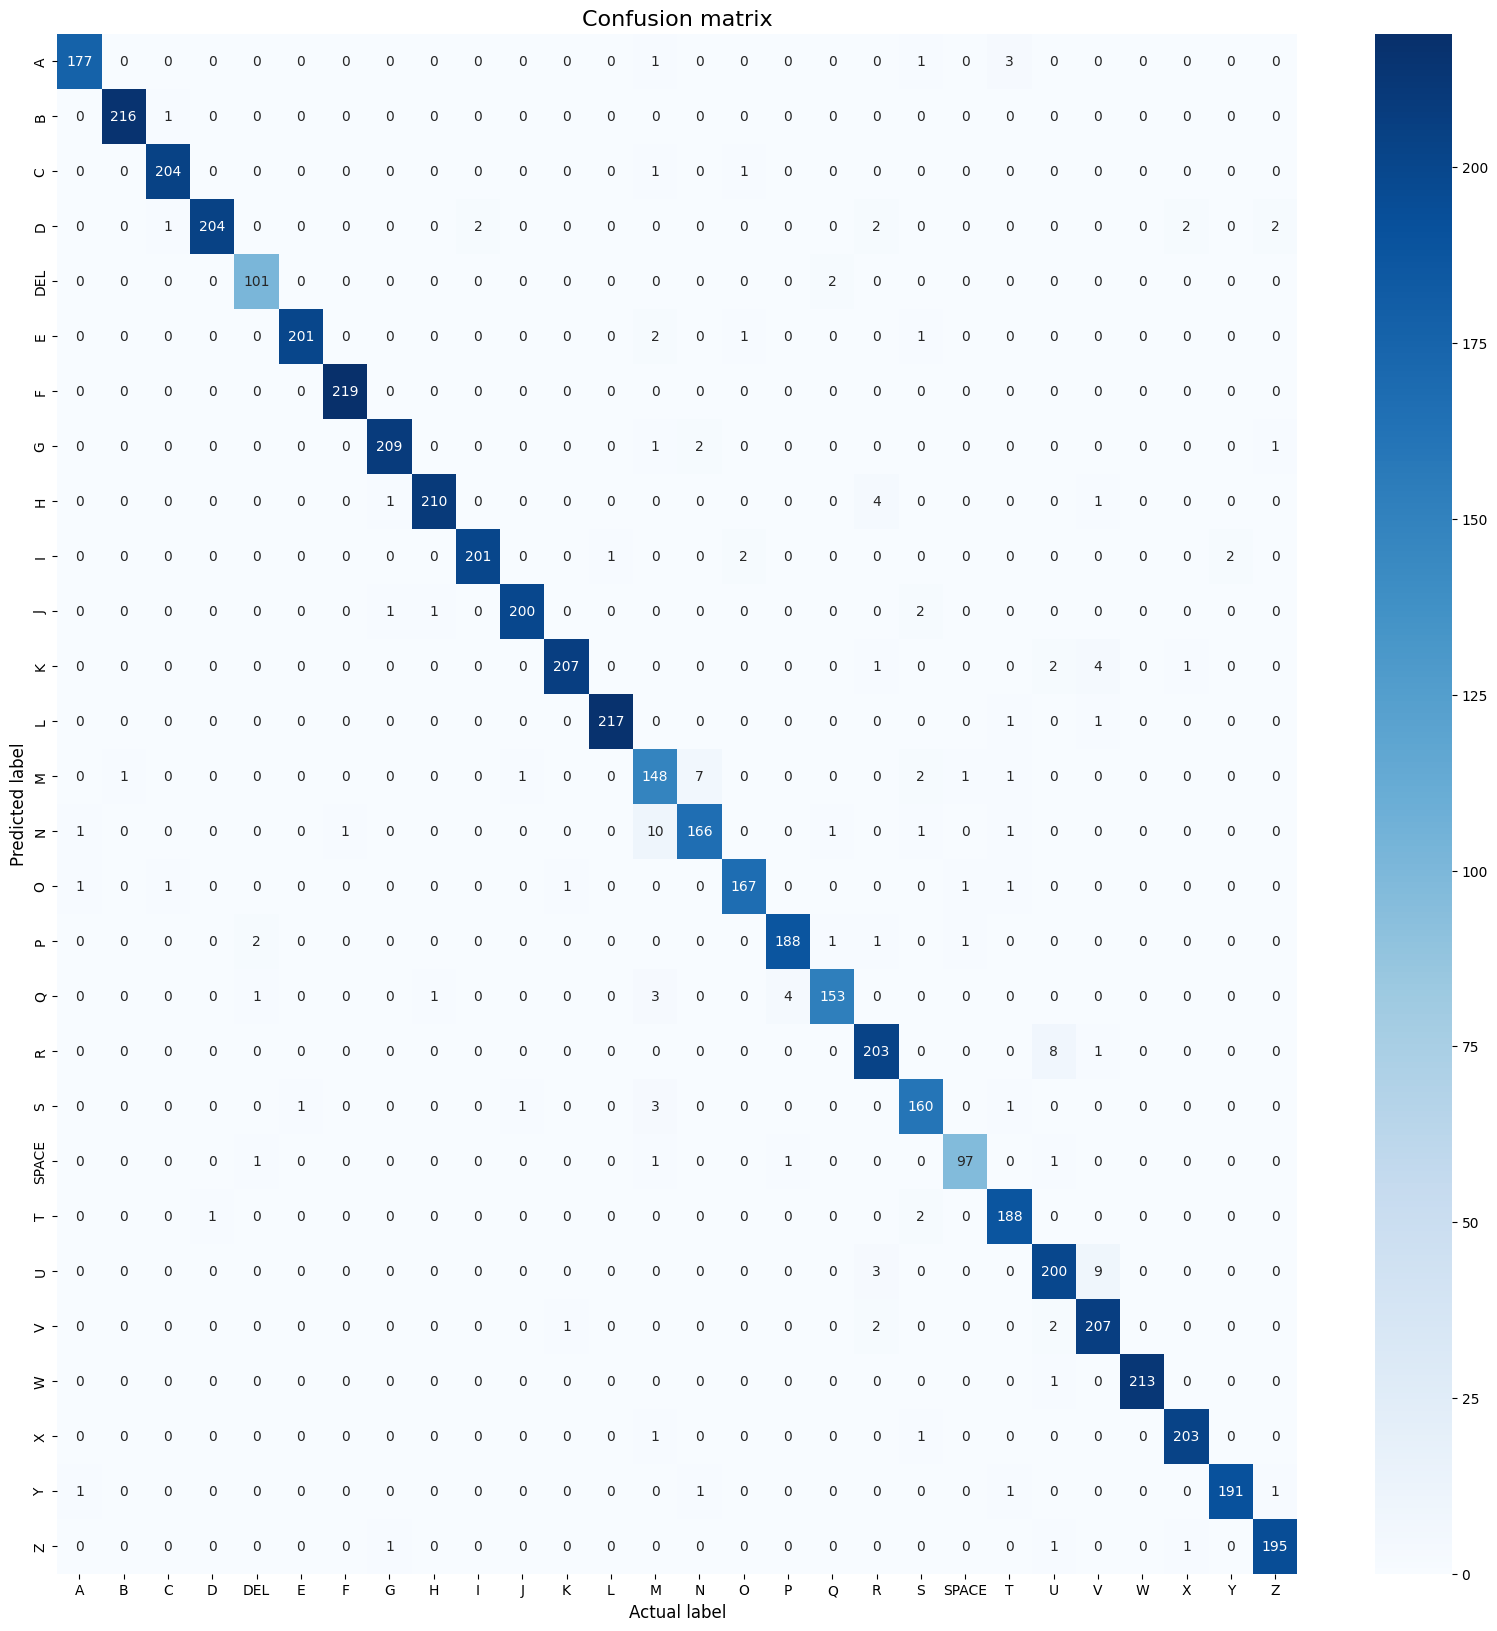

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       182
           1       1.00      1.00      1.00       217
           2       0.99      0.99      0.99       206
           3       1.00      0.96      0.98       213
           4       0.96      0.98      0.97       103
           5       1.00      0.98      0.99       205
           6       1.00      1.00      1.00       219
           7       0.99      0.98      0.98       213
           8       0.99      0.97      0.98       216
           9       0.99      0.98      0.98       206
          10       0.99      0.98      0.99       204
          11       0.99      0.96      0.98       215
          12       1.00      0.99      0.99       219
          13       0.87      0.92      0.89       161
          14       0.94      0.92      0.93       181
          15       0.98      0.97      0.97       172
          16       0.97      0.97      0.97       193
    

In [62]:
import os

# Define the path
gb_dir = "artifact/gradian_boost"
# Create the directory if it does not exist
os.makedirs(gb_dir, exist_ok=True)

print(f"Directory '{gb_dir}' created successfully!")

# Save the model to a file
joblib.dump(gbm, os.path.join(gb_dir,'gbm.joblib'))

# Save the LabelEncoder
joblib.dump(le, os.path.join(gb_dir,'label_encoder.pkl'))

plot_confusion_matrix(gbm, X_test, y_test,gb_dir)

### CatBC

In [ ]:
# Define the parameter grid
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [6, 8, 10, 12]
}


In [33]:
# Initialize the CatBoostClassifier
model = CatBoostClassifier(verbose=0)

In [ ]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')


In [ ]:
# Fit the model to the data
grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [63]:
# Initialize the model
catboost_model = CatBoostClassifier(iterations=30, learning_rate=0.2, depth=12, verbose=1)

In [64]:
# Train the model
catboost_model.fit(X_train, y_train)

0:	learn: 1.5896859	total: 33.9s	remaining: 16m 23s
1:	learn: 1.2170752	total: 1m 7s	remaining: 15m 48s
2:	learn: 0.9917734	total: 1m 39s	remaining: 14m 58s
3:	learn: 0.8310314	total: 2m 11s	remaining: 14m 17s
4:	learn: 0.7121975	total: 2m 44s	remaining: 13m 44s
5:	learn: 0.6046123	total: 3m 18s	remaining: 13m 12s
6:	learn: 0.5273708	total: 3m 50s	remaining: 12m 36s
7:	learn: 0.4652539	total: 4m 22s	remaining: 12m 1s
8:	learn: 0.4143662	total: 4m 56s	remaining: 11m 30s
9:	learn: 0.3686701	total: 5m 28s	remaining: 10m 57s
10:	learn: 0.3310203	total: 6m	remaining: 10m 23s
11:	learn: 0.3004611	total: 6m 33s	remaining: 9m 49s
12:	learn: 0.2764408	total: 7m 6s	remaining: 9m 18s
13:	learn: 0.2541051	total: 7m 38s	remaining: 8m 44s
14:	learn: 0.2322545	total: 8m 11s	remaining: 8m 11s
15:	learn: 0.2151132	total: 8m 44s	remaining: 7m 38s
16:	learn: 0.2002653	total: 9m 17s	remaining: 7m 6s
17:	learn: 0.1866398	total: 9m 49s	remaining: 6m 32s
18:	learn: 0.1743092	total: 10m 21s	remaining: 5m 59s


In [65]:
X_test[0]

array([ 0.10606061,  0.14545455,  0.26060606,  0.37878788,  0.45454545,
        0.30606061,  0.51515152,  0.63333333,  0.72424242,  0.35757576,
        0.58181818,  0.71515152,  0.81515152,  0.38787879,  0.52121212,
        0.45757576,  0.4       ,  0.3969697 ,  0.46060606,  0.4030303 ,
        0.35757576,  0.57575758,  0.44545455,  0.38181818,  0.4030303 ,
        0.44848485,  0.2969697 ,  0.27878788,  0.27878788,  0.27272727,
        0.35757576,  0.34848485,  0.35151515,  0.34545455,  0.43939394,
        0.52727273,  0.56363636,  0.55757576,  0.53030303,  0.61818182,
        0.63939394,  0.62424242,  0.        ,  0.00606061,  0.00606061,
        0.        , -0.0030303 , -0.00909091, -0.01818182, -0.01818182,
       -0.01818182, -0.02121212, -0.02727273, -0.03333333, -0.03333333,
       -0.03030303, -0.03636364, -0.03030303, -0.02121212, -0.03939394,
       -0.03939394, -0.03030303, -0.02121212])

In [66]:
catboost_model.predict(X_test)

array([[ 8],
       [ 7],
       [25],
       ...,
       [26],
       [27],
       [ 8]])

Directory 'artifact/cat_boost' created successfully!


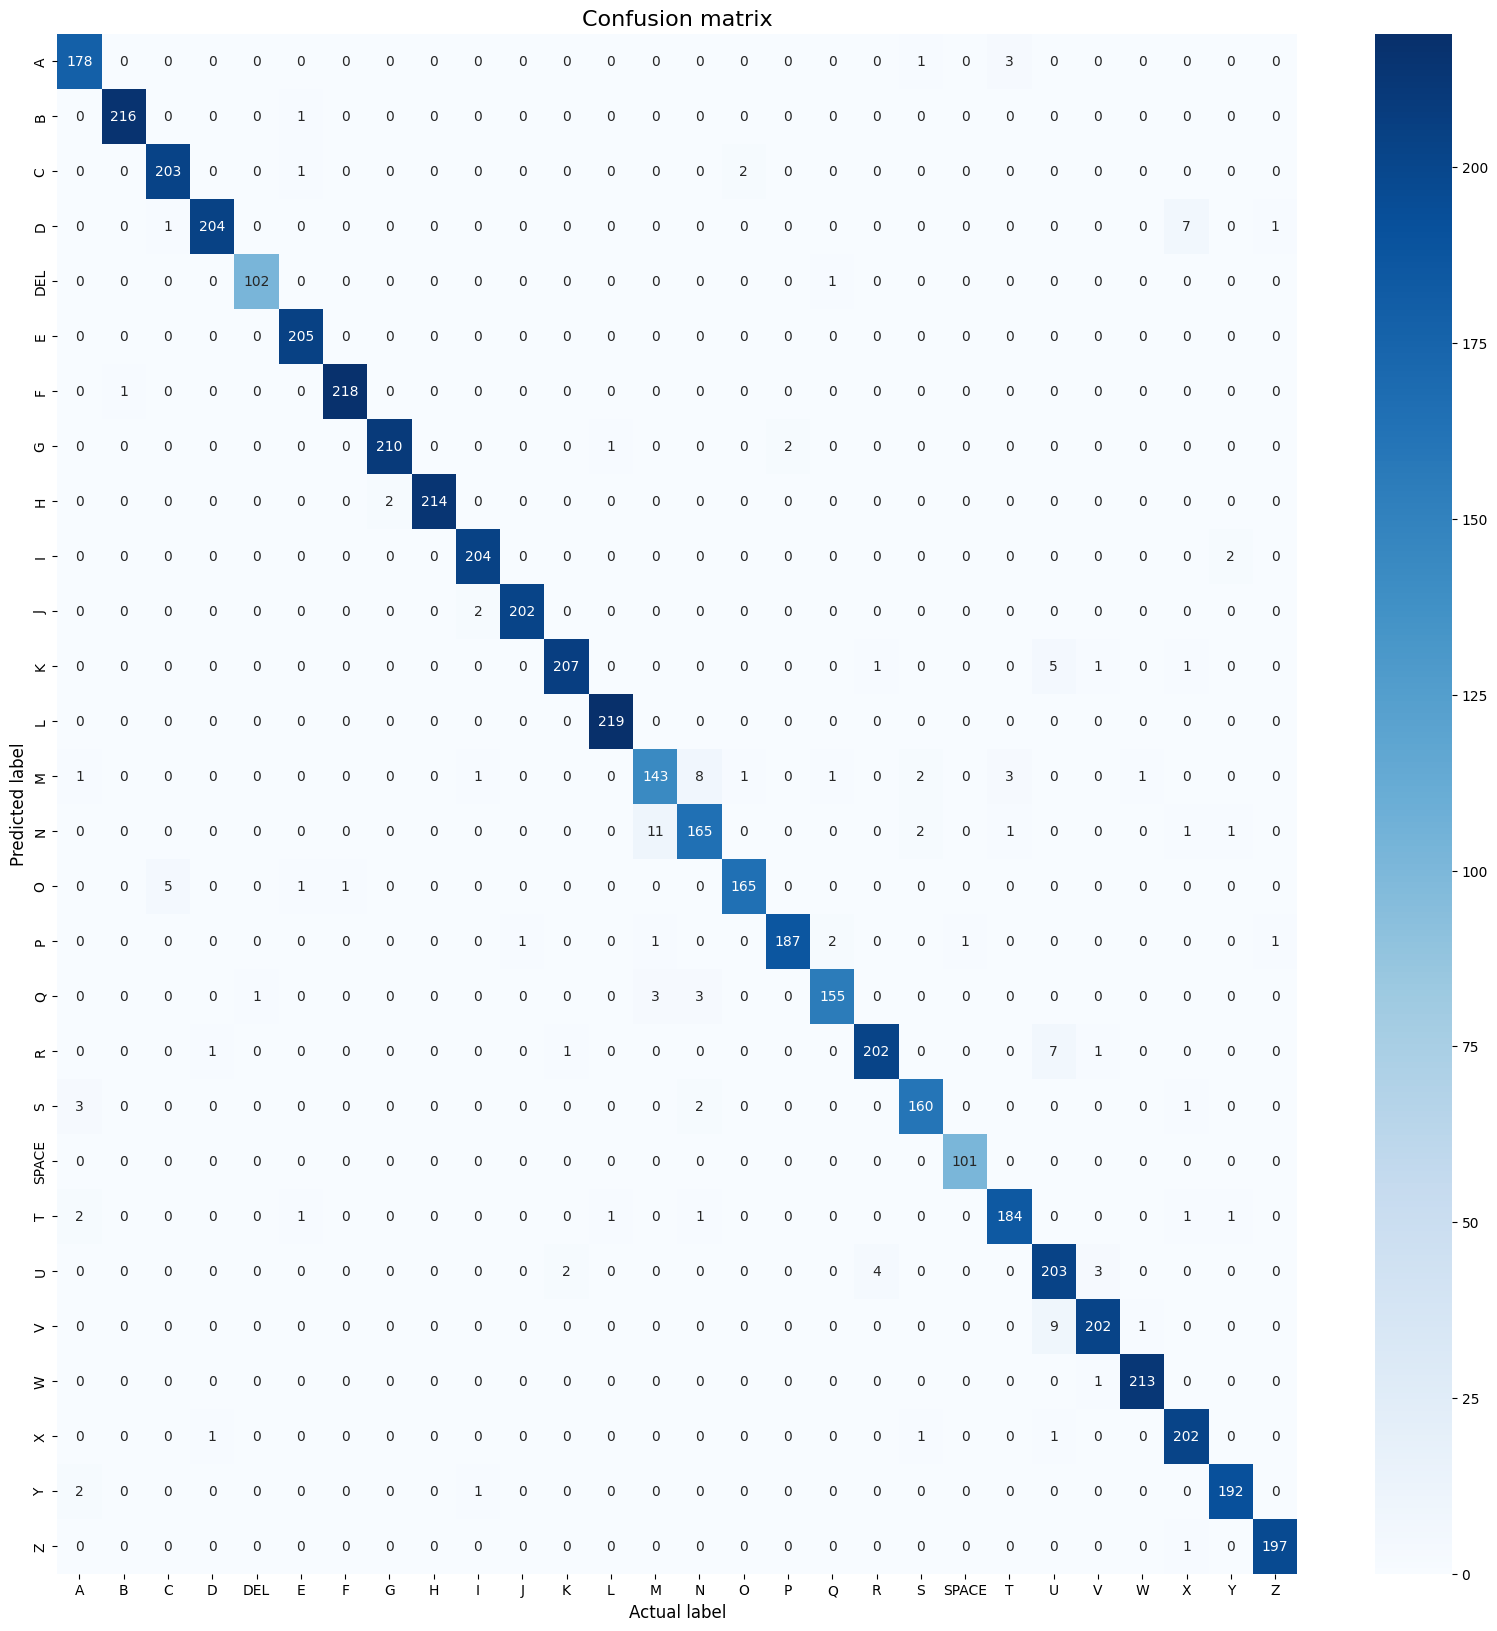

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       182
           1       1.00      1.00      1.00       217
           2       0.97      0.99      0.98       206
           3       0.99      0.96      0.97       213
           4       0.99      0.99      0.99       103
           5       0.98      1.00      0.99       205
           6       1.00      1.00      1.00       219
           7       0.99      0.99      0.99       213
           8       1.00      0.99      1.00       216
           9       0.98      0.99      0.99       206
          10       1.00      0.99      0.99       204
          11       0.99      0.96      0.97       215
          12       0.99      1.00      1.00       219
          13       0.91      0.89      0.90       161
          14       0.92      0.91      0.92       181
          15       0.98      0.96      0.97       172
          16       0.99      0.97      0.98       193
    

In [67]:

import os

# Define the path
cat_dir = "artifact/cat_boost"
# Create the directory if it does not exist
os.makedirs(cat_dir, exist_ok=True)

print(f"Directory '{cat_dir}' created successfully!")

# Save the model to a file
joblib.dump(catboost_model, os.path.join(cat_dir,'cat.joblib'))
# Save the LabelEncoder
joblib.dump(le, os.path.join(cat_dir,'label_encoder.pkl'))

plot_confusion_matrix(catboost_model, X_test, y_test,cat_dir)

###label binanze

In [68]:
print(list(df['Category']))

['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N',

In [69]:
# Initialize the LabelBinarizer
lb = LabelBinarizer()

# Fit and transform the 'Category' column
df['Category_labelBinariz']= list(lb.fit_transform(df['Category']))

Category_labelBinariz= list(lb.fit_transform(df['Category']))

print(lb.classes_)
print(len(lb.classes_))

['A' 'B' 'C' 'D' 'DEL' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q'
 'R' 'S' 'SPACE' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
28


In [70]:
print(Category_labelBinariz)

Output hidden; open in https://colab.research.google.com to view.

In [71]:
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,z15,z16,z17,z18,z19,z20,label,Category,Category_Encoded,Category_labelBinariz
0,126,177,192,167,144,211,213,180,156,167,...,-24,-19,0,-17,-19,-15,N,N,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
1,125,186,192,158,132,216,217,188,163,167,...,-29,-26,0,-18,-24,-22,N,N,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
2,163,103,90,124,163,88,70,82,93,134,...,-20,-13,-11,-21,-18,-12,N,N,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3,157,111,106,136,164,132,106,83,73,166,...,-15,-10,-10,-16,-14,-9,N,N,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4,134,192,214,177,136,191,218,229,222,152,...,-24,-17,-10,-21,-19,-13,N,N,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


In [72]:
# Create a mapping of categories to encoded values
category_mapping = dict(zip( range(0,38),lb.classes_))

print("classes:")
print(lb.classes_)

print("\nCategory to Encoding Mapping:")
print(category_mapping)

classes:
['A' 'B' 'C' 'D' 'DEL' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q'
 'R' 'S' 'SPACE' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

Category to Encoding Mapping:
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'DEL', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'SPACE', 21: 'T', 22: 'U', 23: 'V', 24: 'W', 25: 'X', 26: 'Y', 27: 'Z'}


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

In [74]:
X=df.iloc[:,:63].values
Y=np.array(Category_labelBinariz)
X=X/330
print(X.shape)
print(Y.shape)
print(X)
print(Y)

(26964, 63)
(26964, 28)
[[126 177 192 ... -17 -19 -15]
 [125 186 192 ... -18 -24 -22]
 [163 103  90 ... -21 -18 -12]
 ...
 [228 206 168 ...   1  -1  -3]
 [227 203 165 ...   3   1   0]
 [234 208 165 ...   3   0  -2]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### XGB

In [76]:
# Convert the dataset into an optimized data structure called DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

print(dtrain)
print(dtest)





In [79]:
# Set hyperparameters
params = {
    'objective': 'binary:logistic',  # for binary classification
    'max_depth': 5,
    'eta': 0.1,  # learning rate
    'eval_metric': 'logloss'
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

In [80]:
import os

# Define the path
XGB_dir = "artifact/XGBoost"
# Create the directory if it does not exist
os.makedirs(XGB_dir, exist_ok=True)

print(f"Directory '{XGB_dir}' created successfully!")

# Save the model to a file
joblib.dump(bst , os.path.join(XGB_dir,'cat.joblib'))
# Save the LabelEncoder
joblib.dump(lb, os.path.join(XGB_dir,'label_binanzer.pkl'))

# Make predictions
y_pred = bst.predict(dtest)
y_pred_binary = (y_pred > 0.5).astype(int)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy}")

Directory 'artifact/XGBoost' created successfully!
Accuracy: 0.9740404227702577


In [81]:
import subprocess

# Set environment variables and run the scp command
command = "scp -r /content/artifact '/content/drive/MyDrive/Work_space/Kaushi/ASL_detection/artifact'"
process = subprocess.Popen(command, shell=True, env={"LC_ALL": "C.UTF-8", "LANG": "C.UTF-8"})
process.wait()

0